Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [6]:
df = df[df["job_title_short"]=="Data Analyst"]
df = df[df["job_country"] == "United States"]

df["month"] = df["job_posted_date"].dt.strftime(format("%B"))
df_exploded = df.explode("job_skills")
df_exploded = df_exploded.sort_values(by="job_posted_date")
df_exploded.reset_index(inplace=True)
df_exploded.set_index("month", inplace=True)

df_exploded.dropna(subset="salary_year_avg", inplace=True)
df_exploded.head()

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
month,,,,,,,,,,,,,,,,,,
January,366073,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,tableau,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
January,366073,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,alteryx,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
January,366073,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,excel,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
January,366073,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,matplotlib,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
January,366073,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,pandas,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."


In [4]:
!pip install seaborn

In [5]:
import seaborn as sns
sns

<module 'seaborn' from '/usr/local/lib/python3.13/dist-packages/seaborn/__init__.py'>

In [7]:
top_paid_skills = df_exploded.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=False).head(10)

most_requested_skills = df_exploded.groupby("job_skills")["job_skills"].value_counts().sort_values(ascending=False).head(10)

df_most_requested_skills = df_exploded[df_exploded["job_skills"].isin(most_requested_skills.index.to_list())]
# print(df_most_requested_skills["job_skills"])

most_requested_skills_pay = df_most_requested_skills.groupby("job_skills")["salary_year_avg"].median().sort_values(ascending=False).head(10)

df_most_requested_skills_count = df_exploded[df_exploded["job_skills"].isin(top_paid_skills.index.to_list())]

top_paid_skills_count = df_most_requested_skills_count.groupby("job_skills")["job_skills"].value_counts().sort_values(ascending=False).head(10)

print(top_paid_skills)
print()
print(most_requested_skills)
print()
print(most_requested_skills_pay)
print()
print(top_paid_skills_count)


job_skills
dplyr           196250.0
bitbucket       189000.0
gitlab          186000.0
solidity        179000.0
hugging face    175000.0
couchbase       160515.0
ansible         159640.0
mxnet           149000.0
cassandra       148250.0
vmware          147500.0
Name: salary_year_avg, dtype: float64

job_skills
sql           2508
excel         1808
python        1431
tableau       1364
sas            926
r              893
power bi       838
powerpoint     462
word           461
sql server     286
Name: count, dtype: int64

job_skills
python        97500.00
tableau       92875.00
sql server    92500.00
r             92500.00
sql           91000.00
power bi      90000.00
sas           90000.00
powerpoint    85000.00
excel         84392.00
word          81194.75
Name: salary_year_avg, dtype: float64

job_skills
cassandra       6
bitbucket       3
gitlab          3
dplyr           2
mxnet           2
ansible         1
couchbase       1
hugging face    1
solidity        1
vmware          1
N

# Barplots

/tmp/ipykernel_1629/3105892653.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1629/3105892653.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1629/3105892653.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1629/3105892653.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


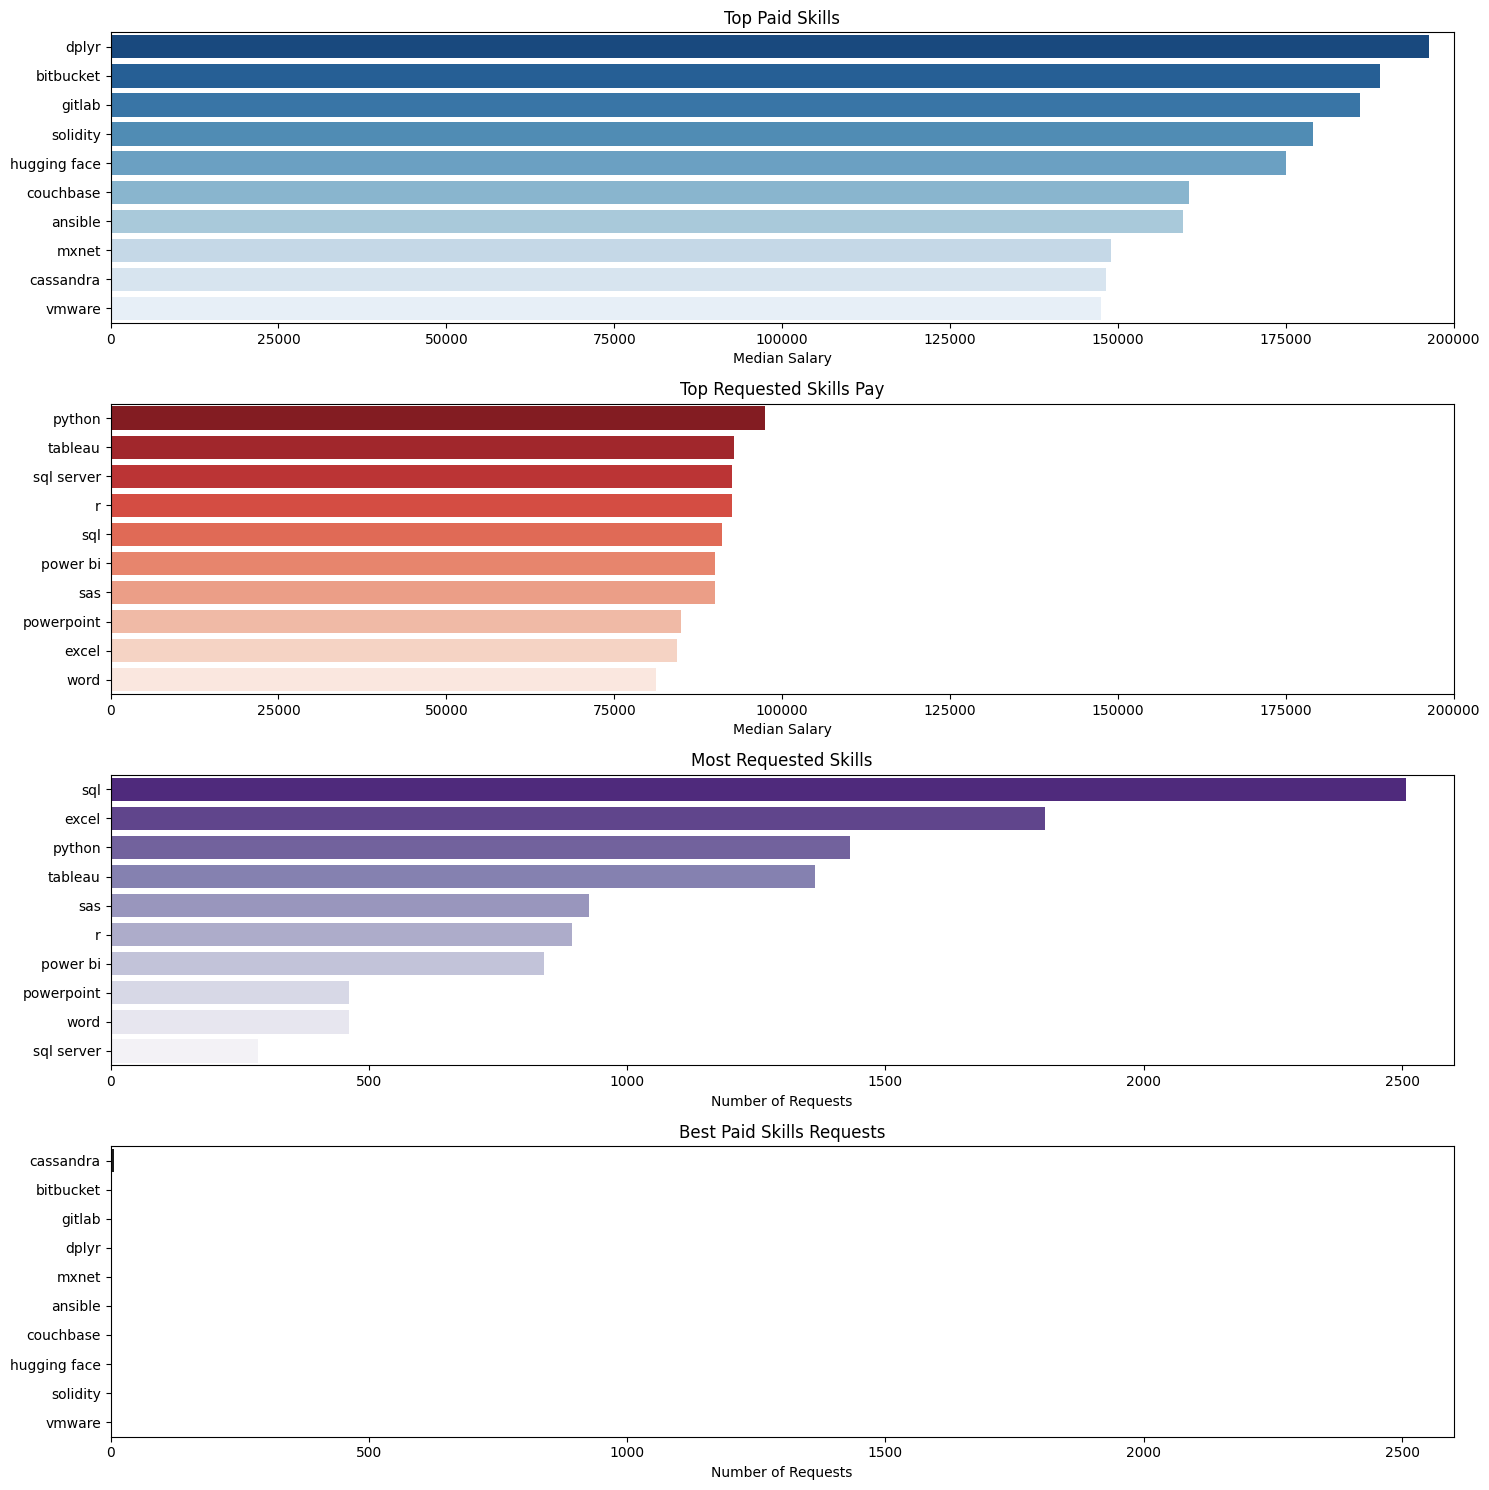

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(4, 1, figsize=(15, 15))

# 1. Top Paid Skills
sns.barplot(
    x=top_paid_skills.values,
    y=top_paid_skills.index,
    ax=ax[0],
    palette="Blues_r" # el _r invierte el pallete
)

ax[0].set_title("Top Paid Skills")
ax[0].set_xlim(0, 200000)
ax[0].set_xlabel("Median Salary")
ax[0].set_ylabel("")


# 2. Most Requested Skills - Pay
sns.barplot(
    x=most_requested_skills_pay.values,
    y=most_requested_skills_pay.index,
    ax=ax[1],
    palette="Reds_r"
)

ax[1].set_title("Top Requested Skills Pay")
ax[1].set_xlim(0, 200000)
ax[1].set_xlabel("Median Salary")
ax[1].set_ylabel("")


# 3. Most Requested Skills
sns.barplot(
    x=most_requested_skills.values,
    y=most_requested_skills.index,
    ax=ax[2],
    palette="Purples_r"
)

ax[2].set_title("Most Requested Skills")
ax[2].set_xlim(0, 2600)
ax[2].set_xlabel("Number of Requests")
ax[2].set_ylabel("")


# 4. Number of requests for the best-paid skills
sns.barplot(
    x=top_paid_skills_count.values,
    y=top_paid_skills_count.index,
    ax=ax[3],
    palette="Grays_r"
)

ax[3].set_title("Best Paid Skills Requests")
ax[3].set_xlim(0, 2600)
ax[3].set_xlabel("Number of Requests")
ax[3].set_ylabel("")


plt.tight_layout()
plt.show()

# Histograms and kde

Text(9.444444444444445, 0.5, 'Frequency')

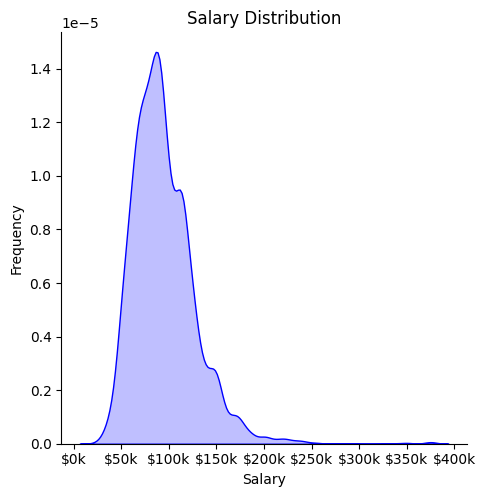

In [26]:
sns.displot(df["salary_year_avg"], kind="kde", fill=True, color="blue")
# sns.displot(df["salary_year_avg"], kind="hist")

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${format(int(x/1000))}k'))

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

# Box plot

In [36]:
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)

df = df[df["job_title_short"].isin(["Data Analyst", "Data Scientist", "Data Engineer"])]
df = df[df["job_country"] == "United States"]

df["month"] = df["job_posted_date"].dt.strftime(format("%B"))


(0.0, 600000.0)

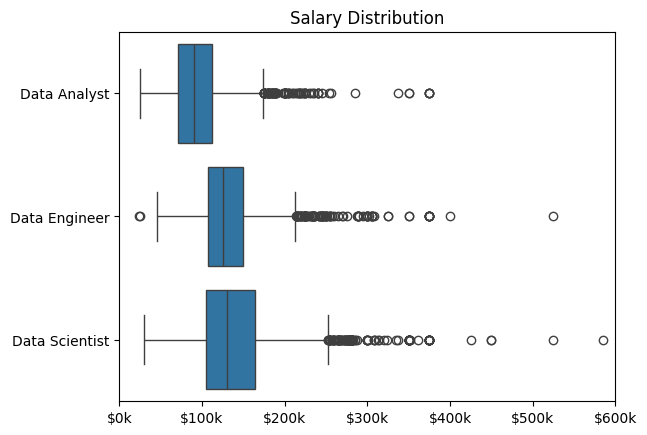

In [39]:
sns.boxplot(df, x="salary_year_avg", y="job_title_short")

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${format(int(x/1000))}k'))
plt.title("Salary Distribution")
plt.xlabel("")
plt.ylabel("")
plt.xlim(0,600000)